## Exploratory Data Analysis ##

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from src.customerchurn.utils import read_yaml


In [ ]:
import sys, pathlib
repo_root = pathlib.Path().cwd().parents[0] 
sys.path.append(str(repo_root))

In [99]:
schema_path = os.path.join(str(repo_root),'configs','schema.yaml')
train_path = os.path.join(str(repo_root),'artifacts','train_data.csv')
test_path = os.path.join(str(repo_root),'artifacts','test_data.csv')

In [100]:
schema = read_yaml(schema_path)
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

target = schema['target_column']

In [101]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7,No
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No


In [102]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2,No
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No
2,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,...,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.2,No
3,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,...,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,No
4,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,No


In [103]:
train_df.shape, test_df.shape, target

((5634, 21), (1409, 21), 'Churn')

 Data and Schema checks - Train

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
tenure_bucket       0
dtype: int64

In [104]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [114]:
train_df.isna().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [115]:
test_df.isna().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [105]:
train_df.describe(include='all').T.head(40)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,5634,5634,6490-FGZAT,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,5634,2,Male,2833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,5634.0,NaN,NaN,NaN,0.163294,0.369667,0.0,0.0,0.0,0.0,1.0
Partner,5634,2,No,2905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,5634,2,No,3955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,5634.0,NaN,NaN,NaN,32.485091,24.568744,0.0,9.0,29.0,55.0,72.0
PhoneService,5634,2,Yes,5075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,5634,3,No,2685,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,5634,3,Fiber optic,2483,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,5634,3,No,2797,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [158]:
train_df.duplicated().sum()
test_df.duplicated().sum()

np.int64(0)

In [106]:
# Checking required columns

missing = [c for c in schema['required_columns'] if c not in train_df.columns]
missing

[]

In [161]:
def column_checker(df):
    categ_col = [col for col in df.columns if df[col].dtype == "O"]
    number_cols = [col for col in df.columns if df[col].dtype != "O"]
    
    return categ_col, number_cols

train_cc = column_checker(train_df)
test_cc = column_checker(test_df)

train_cc, test_cc


((['customerID',
   'gender',
   'Partner',
   'Dependents',
   'PhoneService',
   'MultipleLines',
   'InternetService',
   'OnlineSecurity',
   'OnlineBackup',
   'DeviceProtection',
   'TechSupport',
   'StreamingTV',
   'StreamingMovies',
   'Contract',
   'PaperlessBilling',
   'PaymentMethod',
   'TotalCharges',
   'Churn'],
  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'tenure_bucket']),
 (['customerID',
   'gender',
   'Partner',
   'Dependents',
   'PhoneService',
   'MultipleLines',
   'InternetService',
   'OnlineSecurity',
   'OnlineBackup',
   'DeviceProtection',
   'TechSupport',
   'StreamingTV',
   'StreamingMovies',
   'Contract',
   'PaperlessBilling',
   'PaymentMethod',
   'TotalCharges',
   'Churn'],
  ['SeniorCitizen', 'tenure', 'MonthlyCharges']))

## Target churn distribution(Is it Stratifed) ##

In [111]:
def churn_rate(df, target):
    vc = df[target].value_counts(dropna=False)
    return vc, (df[target].value_counts(normalize=True)*100).round(2)

train_vc, train_pct = churn_rate(train_df,target)
test_vc, test_pct = churn_rate(test_df,target)

train_vc,train_pct,test_vc,test_pct

(Churn
 No     4139
 Yes    1495
 Name: count, dtype: int64,
 Churn
 No     73.46
 Yes    26.54
 Name: proportion, dtype: float64,
 Churn
 No     1035
 Yes     374
 Name: count, dtype: int64,
 Churn
 No     73.46
 Yes    26.54
 Name: proportion, dtype: float64)

About 1 in 4 customer churned and 3 in 4 customer did not

From the data we can say that train and test both have the same churn percentage, the split is stratified.



### Earlier we foung out there are some null values in Total Charges column with value "". ###

In [ ]:
train_df['TotalCharges']

array(['1701.65', '1151.55', '590.35', ..., '80.35', '2660.2', '109.3'],
      dtype=object)

In [133]:
print(f"Train df has:",(train_df['TotalCharges'].astype(str).str.strip()=="").sum(), "missing values")
print(f"Test df has:",(test_df['TotalCharges'].astype(str).str.strip()=="").sum(), "missing values")



Train df has: 8 missing values
Test df has: 3 missing values


In [132]:
import numpy as np

train_tc = pd.to_numeric(train_df['TotalCharges'].astype(str).str.strip().replace({"":np.nan}), errors="coerce")
test_tc = pd.to_numeric(test_df['TotalCharges'].astype(str).str.strip().replace({"":np.nan}), errors="coerce")

train_tc.isna().sum(), test_tc.isna().sum()

(np.int64(8), np.int64(3))

In [139]:
train_df.loc[train_tc.isna(),"tenure"].describe()

count    8.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: tenure, dtype: float64

In [140]:
test_df.loc[test_tc.isna(),"tenure"].describe()

count    3.0
mean     0.0
std      0.0
min      0.0
25%      0.0
50%      0.0
75%      0.0
max      0.0
Name: tenure, dtype: float64

## Univariate drivers

In [144]:
cat_cols = schema["categorical_columns"]
cat_cols = [c for c in cat_cols if c != target]


def churn_rate(df,col,target):
    return(df.groupby(col)[target]
           .apply(lambda s: (s=="Yes").mean()*100)
           .sort_values(ascending=False)
           .to_frame("churn_rate")
           .assign(count=df[col].value_counts())
           )

for c in ["Contract","InternetService","TechSupport","OnlineSecurity","PaymentMethod","PaperlessBilling"]:
    display(c, churn_rate(train_df,c,target).head(10))

'Contract'

,churn_rate,count
Contract,,
Month-to-month,42.746615,3102
One year,11.082694,1173
Two year,2.869757,1359


'InternetService'

,churn_rate,count
InternetService,,
Fiber optic,42.086186,2483
DSL,18.688694,1937
No,7.248764,1214


'TechSupport'

...

,churn_rate,count
OnlineSecurity,,
No,41.937790,2797
Yes,14.417745,1623
No internet service,7.248764,1214


'PaymentMethod'

,churn_rate,count
PaymentMethod,,
Electronic check,45.742993,1891
Mailed check,19.284603,1286
Bank transfer (automatic),16.157556,1244
Credit card (automatic),14.921682,1213


'PaperlessBilling'

,churn_rate,count
PaperlessBilling,,
Yes,33.803663,3331
No,16.022579,2303


In [145]:
for c in ["Contract","InternetService","TechSupport","OnlineSecurity","PaymentMethod","PaperlessBilling"]:
    display(c, churn_rate(test_df,c,target).head(10))

'Contract'

,churn_rate,count
Contract,,
Month-to-month,42.561449,773
One year,12.000000,300
Two year,2.678571,336


'InternetService'

,churn_rate,count
InternetService,,
Fiber optic,41.109299,613
DSL,20.041322,484
No,8.012821,312


'TechSupport'

...

,churn_rate,count
OnlineSecurity,,
No,41.084165,701
Yes,15.404040,396
No internet service,8.012821,312


'PaymentMethod'

,churn_rate,count
PaymentMethod,,
Electronic check,43.459916,474
Bank transfer (automatic),19.000000,300
Mailed check,18.404908,326
Credit card (automatic),16.504854,309


'PaperlessBilling'

,churn_rate,count
PaperlessBilling,,
Yes,32.619048,840
No,17.574692,569


#### For numerical columns ####

In [147]:
num_cols = schema['numeric_columns']
train_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,5634.0,32.485091,24.568744,0.0,9.0000,29.0,55.0,72.00
MonthlyCharges,5634.0,64.929961,30.138105,18.4,35.6625,70.5,90.0,118.75


In [ ]:
target_col = "Churn"
bins = [0,3,6,12,24,48,72,np.inf]
labels = ["0-3","3-6","6-12","12-24","24-48","48-72","72+"]

train_df["tenure_bucket"] = pd.cut(train_df['tenure'],bins=bins,labels=labels,right=False)

rates = (
    train_df.groupby("tenure_bucket")[target_col]
    .apply(lambda s:(s=="Yes").mean())
    .sort_values(ascending=False)
    .to_frame("churn_rate")
    )

out = rates.assign(count=train_df['tenure_bucket'].value_counts())
out

C:\Users\Admin\AppData\Local\Temp\ipykernel_7824\1813569371.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby("tenure_bucket")[target_col]


,churn_rate,count
tenure_bucket,,
0-3,0.574780,682
3-6,0.465000,400
6-12,0.381295,556
12-24,0.295024,844
24-48,0.207317,1312
48-72,0.115633,1548
72+,0.017123,292


### Here, Customer in 0-3 months have churn rate 57%, followed up by 3-6 with 45%. While customers with tenure 48 or above have least churn rate

In [164]:
train_df['customerID'].duplicated().sum(), test_df['customerID'].duplicated().sum()

(np.int64(0), np.int64(0))

In [165]:
[target in schema.get("categorical_cols",[])]

[False]

# Visualization

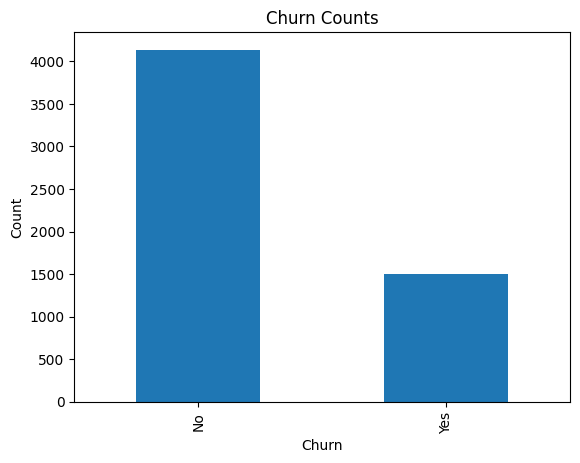

In [169]:
train_df[target].value_counts().plot(kind='bar')
plt.title("Churn Counts")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

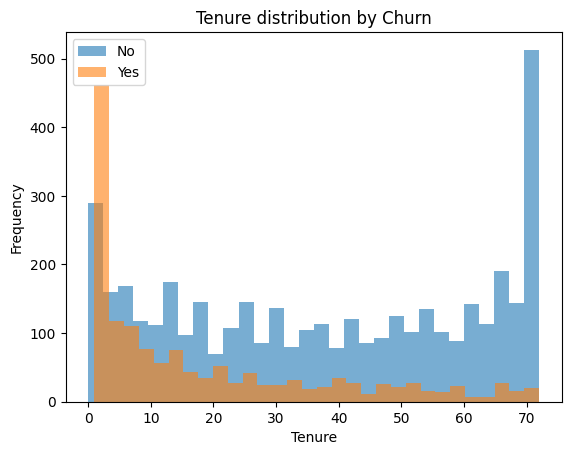

In [179]:
# Tenure Vs churn
plt.figure()
train_df[train_df[target]=="No"]["tenure"].plot(kind="hist",bins=30,label="No",alpha=0.6)
train_df[train_df[target]=="Yes"]["tenure"].plot(kind="hist",bins=30,label="Yes",alpha=0.6)
plt.title("Tenure distribution by Churn")
plt.xlabel("Tenure")
plt.legend()
plt.show()

From the chart, we can see that customer with tenure between 0-6 are the one with most chances to be churn
While customer, between 65-75 have the least chance to churn

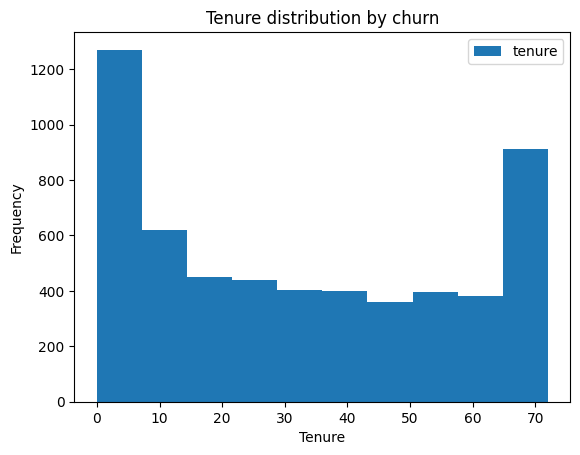

In [178]:

plt.figure
train_df["tenure"].plot(kind="hist")
plt.title("Tenure distribution by churn")
plt.xlabel("Tenure") 
plt.legend()
plt.show()


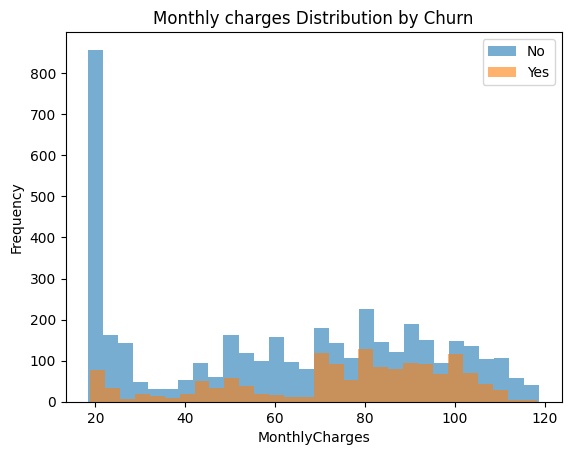

In [183]:
# Monthly Charges Vs churn

plt.figure()
train_df[train_df[target]=="No"]["MonthlyCharges"].plot(kind="hist",bins=30,alpha=0.6,label="No")
train_df[train_df[target]=="Yes"]["MonthlyCharges"].plot(kind="hist",bins=30,alpha=0.6,label="Yes")
plt.title("Monthly charges Distribution by Churn")
plt.xlabel("MonthlyCharges")
plt.legend()
plt.show()


We can see that, customer whose monthly charge is between 70-120 are the one to churn, While customer whose monthly charge is between 10-30 are not churned

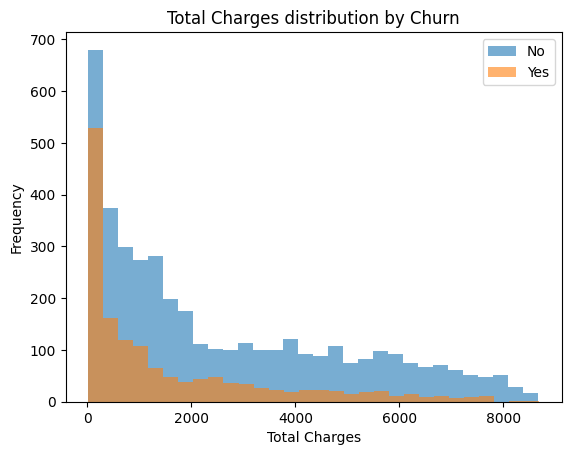

In [186]:
# TotalCharges Vs Churn


plt.figure()
train_tc.loc[train_df[target]=="No"].plot(kind="hist",bins=30,alpha=0.6,label="No")
train_tc.loc[train_df[target]=="Yes"].plot(kind="hist",bins=30,alpha=0.6,label="Yes")

plt.title('Total Charges distribution by Churn')
plt.xlabel('Total Charges')
plt.legend()
plt.show()


Here we can say that TotalCharges is helpul but not sufficiant alone

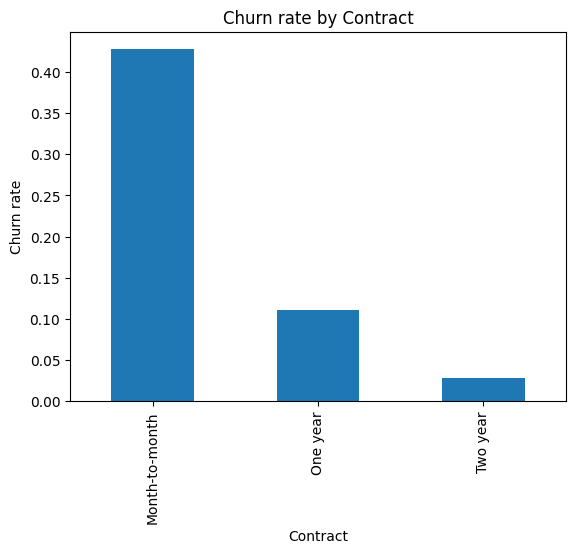

In [187]:
churn_rate_contract = train_df.groupby("Contract")[target].apply(lambda s: (s=="Yes").mean()).sort_values(ascending=False)
plt.figure()
churn_rate_contract.plot(kind="bar")
plt.title("Churn rate by Contract")
plt.ylabel("Churn rate")
plt.show()


Customer with Month-to-Month plan are the highest churn

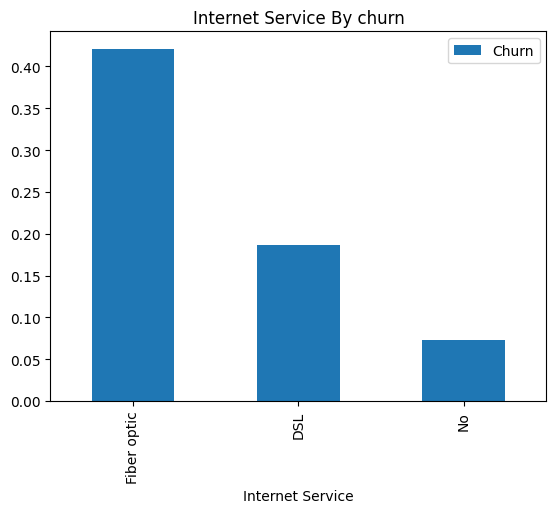

In [190]:
# Internet vs churn

internet_churn_rate = train_df.groupby('InternetService')[target].apply(lambda s:(s=="Yes").mean()).sort_values(ascending=False)
# plt.figure()
internet_churn_rate.plot(kind="bar")
plt.title("Internet Service By churn")
plt.xlabel("Internet Service")
plt.legend()
plt.show()

Customer opted out for fiber optic churns the most

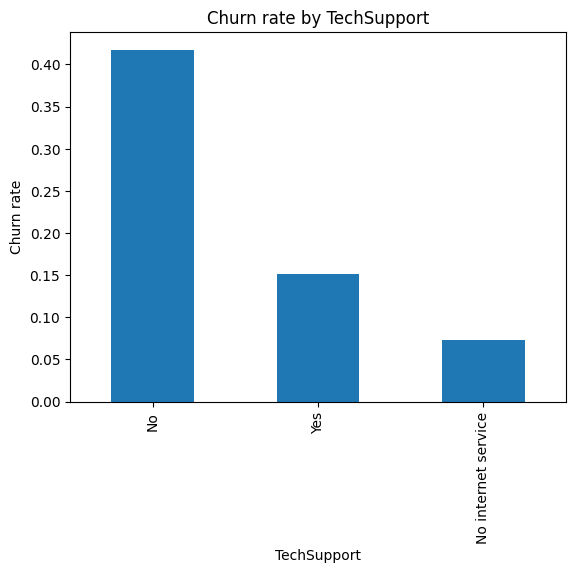

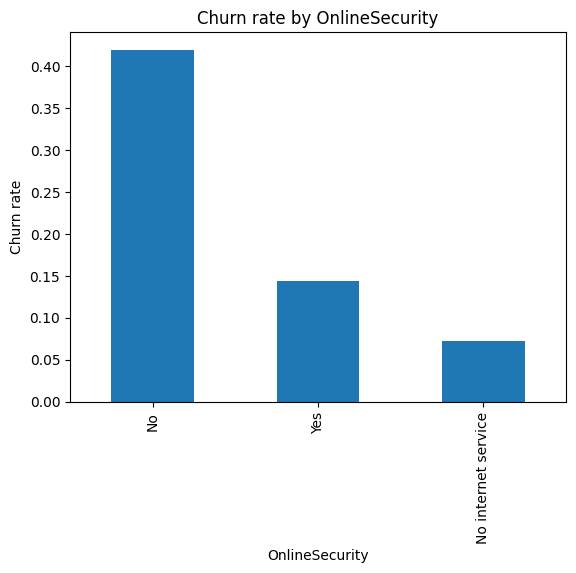

In [191]:
for col in ["TechSupport", "OnlineSecurity"]:
    cr = train_df.groupby(col)[target].apply(lambda s: (s=="Yes").mean()).sort_values(ascending=False)
    plt.figure()
    cr.plot(kind="bar")
    plt.title(f"Churn rate by {col}")
    plt.ylabel("Churn rate")
    plt.show()


Customer who did not get timely tech support are among the highest churns

Customer who dont opt out for Online security are open to cyber attack tend to churn

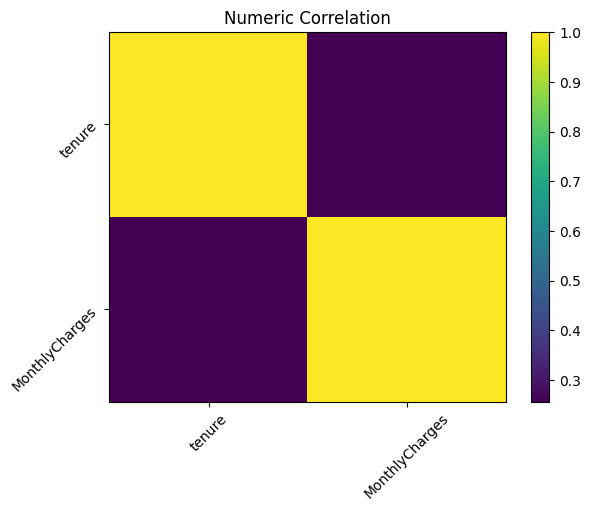

In [193]:
# Correlation Heatmap

corr = train_df[['tenure','MonthlyCharges','TotalCharges']].corr(numeric_only=True)
plt.figure()
plt.imshow(corr,aspect="auto")
plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.yticks(range(len(corr.columns)),corr.columns,rotation=45)
plt.colorbar()
plt.title('Numeric Correlation')
plt.show()